# Earthquake Analysis: Global Patterns & Trends
### By Farid Ahmad Hamidi & Theresia
This project analyzes global earthquake activity using historical seismic data.
The goal is to understand how earthquake frequency, magnitude, and depth have changed over time, and to identify which regions are most affected by seismic events.

The analysis includes:

    Data cleaning and preprocessing

    Exploratory data analysis (EDA)

    Trend analysis over time

    Magnitude and depth distribution

    Identification of global earthquake hotspots

    Visualizations to support insights

This project is part of the ReDI School Data Analytics Final Project, demonstrating skills in Python, pandas, data cleaning, and data visualization.

📘 Notebook Structure
This notebook is organized into five main parts, matching the work completed inside the project.

1. Part 1 — Project Setup & Introduction
Project overview

    Dataset description

    Research questions

    Short Research Questions

    How many earthquakes occur each year?

    Which regions experience the most earthquakes?

    How are earthquake magnitudes distributed?

    What is the relationship between depth and magnitude?

    What are the strongest earthquakes in the dataset?

2. Part 2 — Data Cleaning
    Fixing datetime format

    Handling missing values

    Converting numeric columns

    Creating new columns (year, month, decade)

    Preparing the dataset for analysis

3. Part 3 — Analysis & Visualizations
    Earthquakes per year

    Magnitude distribution

    Depth distribution

    Top 10 strongest earthquakes

    Earthquakes by region

4. Part 4 — Conclusions & Recommendations
    Key findings

    Insights about global earthquake patterns

    Recommendations based on the data

5. Part 5 — Tableau Dashboard 
    Link
    Pre Image view

6. Part 6 - Final Summary Table
    A clean overview of all questions, analyses, and insights
    


## Part 1: Project Setup & Understanding the Data

In [1]:
#This code loads the earthquake dataset into a pandas DataFrame and shows the first five
# rows so you can quickly see what the data looks like.
import pandas as pd
import numpy as np

df = pd.read_csv("../data/RAW_MATARIALS/earthquakes_global_raw.csv")
df.head()


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


#### For my own reference, the following 5 Cells, they are just for understanding the dataset.

In [2]:
# Show number of rows and columns in the dataset.
df.shape


(23412, 21)

In [3]:
# Show column names in the dataset.
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='object')

In [4]:
# Show data types and memory information about the dataset.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [5]:
# with this code we can see the basic statistical summary of the numerical columns in the dataset, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum values.
df.describe()


,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


In [6]:
# with this code we can check for missing values in each column of the dataset. It will return a count of how many missing (NaN) values are present in each column, which is important for data cleaning and analysis.
df.isna().sum()

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

#### The above output shows: how many missing (NaN) values each column has in your dataset.
Columns like Depth Error, Magnitude Error, Horizontal Distance, etc., have many missing values — this is normal in earthquake datasets because not all measurements are recorded for every event

### 🟦 Insight: Project Setup & Understanding the Data
Insight:  
The initial exploration shows that the earthquake dataset is large,
well‑structured, and contains key information such as date,
time, magnitude, depth, and location. Several columns have many missing values,
especially measurement‑related fields, which means cleaning is necessary before analysis.
Overall, the dataset is suitable for studying global earthquake patterns over time.

## Part 2: Data Cleaning & Preparation.

In [7]:
# Combine Date + Time into one datetime column
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df[['Date', 'Time', 'datetime']].head()

#  Short explanation: This creates one clean datetime column by combining
# the Date and Time columns.

,Date,Time,datetime
0,01/02/1965,13:44:18,1965-01-02 13:44:18
1,01/04/1965,11:29:49,1965-01-04 11:29:49
2,01/05/1965,18:05:58,1965-01-05 18:05:58
3,01/08/1965,18:49:43,1965-01-08 18:49:43
4,01/09/1965,13:32:50,1965-01-09 13:32:50


In [8]:
# With this code we can Drop or remove rows where datetime failed to convert.
df = df.dropna(subset=['datetime'])
# This removes rows where the date or time was invalid.
df[['Date', 'Time', 'datetime']].head()


,Date,Time,datetime
0,01/02/1965,13:44:18,1965-01-02 13:44:18
1,01/04/1965,11:29:49,1965-01-04 11:29:49
2,01/05/1965,18:05:58,1965-01-05 18:05:58
3,01/08/1965,18:49:43,1965-01-08 18:49:43
4,01/09/1965,13:32:50,1965-01-09 13:32:50


In [9]:
# Convert important columns to numeric.
numeric_cols = ['Latitude', 'Longitude', 'Depth', 'Magnitude']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# This makes sure Latitude, Longitude, Depth, and Magnitude are numeric values.
# lets check.
df[['Magnitude', 'Depth']].head()


,Magnitude,Depth
0,6.0,131.6
1,5.8,80.0
2,6.2,20.0
3,5.8,15.0
4,5.8,15.0


In [10]:
# Convert datetime column to proper datetime format
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Create new time-based columns
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['decade'] = (df['year'] // 10) * 10


In [11]:
# Remove rows with missing Depth or Magnitude.
df = df.dropna(subset=['Magnitude', 'Depth'])
# We remove rows where the most important values (magnitude or depth) are missing.
df[['year', 'month', 'day', 'decade']].head()


,year,month,day,decade
0,1965,1,2,1960
1,1965,1,4,1960
2,1965,1,5,1960
3,1965,1,8,1960
4,1965,1,9,1960


In [12]:
# Here we create new time-based columns for year, month, day, and decade by extracting this information from the datetime column.
# This will allow us to analyze earthquake patterns over time.

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['decade'] = (df['year'] // 10) * 10

# This creates new columns so we can analyze earthquakes by year, month, and decade.
df.shape

(23409, 26)

### 🟩 Insight: Data Cleaning & Preparation
Insight:  
After cleaning, the dataset now has consistent datetime formatting,
numeric values for magnitude and depth, and new time‑based features (year, month, decade) that make
analysis easier. Invalid or incomplete rows were removed, resulting in a clean dataset of
23,409 earthquakes ready for visualization and deeper analysis.

## Part 3: Analysis & Visualizations

#### 3.1 Statiscical Summary
Here We go with basic statistics to have a good understanding of the Central tendencies, spread, and relationships in the earthquake dataset.

In [ ]:
#Mean Magnitude
df['Magnitude'].mean()
# Note:  Mean = average magnitude. Helps understand the “typical” earthquake strength.

5.882558417702829

Ignore if you already know! this is just a quick tips for those who didnt understand:

What this code does:  
Calculates the average strength of all earthquakes.

Our result: 5.88

Then we can understand that:  
Earthquakes in this dataset are usually around magnitude 5.9, which is considered moderate.


In [34]:
# Median Depth
df['Depth'].median()
# Note:  Median = middle value of depth. Useful for understanding typical earthquake depth, especially if there are outliers.


33.0

Ignore if you already know! this is just a quick tips for those who didnt understand:

What this code does:  
Finds the middle depth when all depths are sorted.

Our result: 33.0

Meaning (simple):  
Half of all earthquakes occur shallower than 33 km, and half occur deeper.

In [29]:
# Minimum & Maximum Magnitude
df['Magnitude'].min(), df['Magnitude'].max()
# Note:  Shows the weakest and strongest earthquakes in the dataset.

(5.5, 9.1)

Ignore if you already know! this is just a quick tips for those who didnt understand well:

What this code does:  
Shows the weakest and strongest earthquakes in the dataset.

Your result: (5.5, 9.1)

Then we can get:

    The smallest earthquakes recorded were 5.5

    The strongest reached 9.1, which is extremely powerful

In [ ]:
# Standard Deviation of Magnitude
df['Magnitude'].std()
# Note:  Standard deviation = how spread out magnitudes are.
# High = big variation, low = similar magnitudes.

0.42308434397171224

Ignore if you already know! this is just a quick tips for those who didnt understand well:

What this code does:  
Measures how spread out the magnitudes are.

Our result: 0.42

Meaning:  
Magnitudes do not vary a lot — most earthquakes are close to the average (around 5.8–6.0).


In [30]:
# Correlation Between Depth and Magnitude
df[['Depth', 'Magnitude']].corr()
#           Note:  
#          *Correlation tells if deeper earthquakes are stronger.
#           Values:

#           1 = strong positive

#           0 = no relationship

#          -1 = strong negative*

,Depth,Magnitude
Depth,1.000000,0.023584
Magnitude,0.023584,1.000000


Ignore if you already know! this is just a quick tips for those who didnt understand well:

What this code does:  
Checks if deeper earthquakes are stronger.

Our result: 0.023

Meaning (simple):  
There is almost no relationship between depth and magnitude.
Deep earthquakes are not necessarily stronger.

In [31]:
# Frequency Count by Region
df['Region'].value_counts()
# Note:  Shows which regions have the most earthquakes.


Oceania          6386
Asia             5644
South America    5057
North America    2678
Africa/Europe    1908
Other            1736
Name: Region, dtype: int64

Ignore if you already know! this is just a quick tips for those who didnt understand well:

What this code does:  
Counts how many earthquakes happened in each region.

Our result (top 3):

    Oceania — 6386

    Asia — 5644

    South America — 5057

Meaning (simple):  
Most earthquakes happen in Oceania, Asia, and South America, which are part of the Pacific Ring of Fire.

In [32]:
# Describe Summary (Quick Overview)
df[['Magnitude', 'Depth']].describe()
# Note:  Gives count, mean, std, min, max — a full statistical snapshot.

,Magnitude,Depth
count,23409.000000,23409.000000
mean,5.882558,70.748526
std,0.423084,122.605748
min,5.500000,-1.100000
25%,5.600000,14.530000
50%,5.700000,33.000000
75%,6.000000,54.000000
max,9.100000,700.000000


Ignore if you already know! this is just a quick tips for those who didnt understand well:

What this code does:  
Gives a full statistical summary:
count, mean, std, min, max, quartiles.

Our key results:

    Mean magnitude: 5.88

    Mean depth: 70.7 km

    Median depth: 33 km

    Max depth: 700 km

Meaning:  
Most earthquakes are moderate and shallow, but some go extremely deep.

INSIGHT SUMMARY:

Statistical analysis shows that global earthquakes in this dataset are mostly moderate in strength, with an average magnitude of around 5.9. Depth varies widely, but half of all earthquakes occur above 33 km, meaning most are relatively shallow. The correlation between depth and magnitude is almost zero, showing that deeper earthquakes are not necessarily stronger.

The highest activity is found in Oceania, Asia, and South America — regions located along the Pacific Ring of Fire. Overall, the statistics confirm clear global patterns: moderate magnitudes, shallow depths, and strong regional concentration.

#### 3.2 Analysis & Visualization

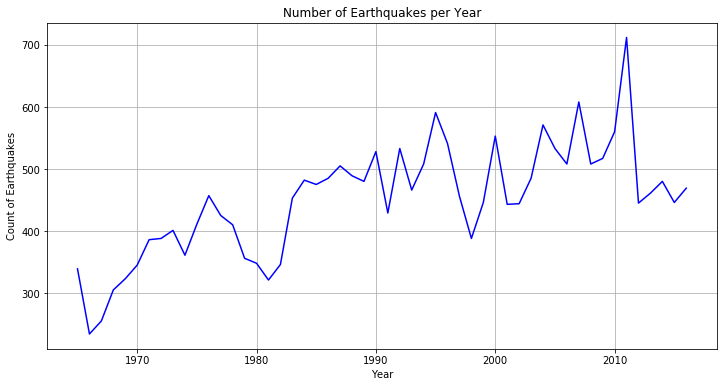

In [13]:
# Analysis 1: Number of Earthquakes per Year
import matplotlib.pyplot as plt

earthquakes_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(earthquakes_per_year.index, earthquakes_per_year.values, color='blue')
plt.title("Number of Earthquakes per Year")
plt.xlabel("Year")
plt.ylabel("Count of Earthquakes")
plt.grid(True)
plt.show()

# This chart shows how many earthquakes happened each year to reveal long‑term trends.

Insight just for the above chart:

⭐ This is the answer to Question 1.

The number of recorded earthquakes rises steadily over time,
peaking around 2010. This increase likely reflects improvements in global monitoring and
reporting systems rather than a sudden rise in earthquake activity.

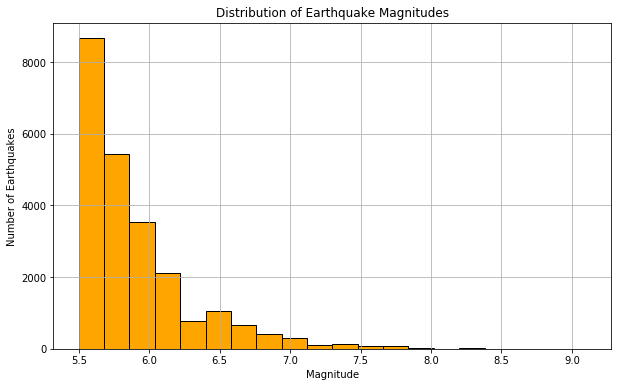

In [14]:
# Analysis 2: Magnitude Distribution

plt.figure(figsize=(10,6))
plt.hist(df['Magnitude'], bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Earthquake Magnitudes")
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.grid(True)
plt.show()

# This histogram shows how earthquake magnitudes
# are distributed — most are moderate, few are very strong.

🟧 Analysis 2 — Magnitude Distribution:

This is the answer to Question 2: “How are earthquake magnitudes distributed?”

Insight:  
Most earthquakes are moderate in strength, clustering around
magnitudes 5.5–6.0. The frequency drops sharply for stronger quakes,
showing that large‑magnitude events are rare but potentially more destructive.

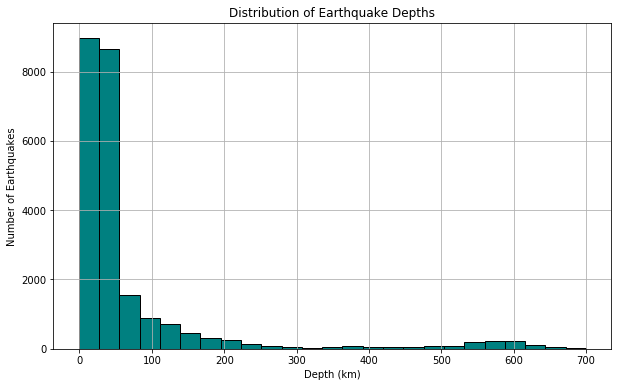

In [15]:
# 🌍 Analysis 3 — Depth Distribution
# This histogram shows how deep earthquakes happen — most occur near the surface,
# fewer at great depths.

plt.figure(figsize=(10,6))
plt.hist(df['Depth'], bins=25, color='teal', edgecolor='black')
plt.title("Distribution of Earthquake Depths")
plt.xlabel("Depth (km)")
plt.ylabel("Number of Earthquakes")
plt.grid(True)
plt.show()


🟩 Analysis 3 — Depth Distribution
This is the answer to Question 3 (How are earthquake magnitudes distributed?).

Insight:  
Most earthquakes happen near the Earth’s surface, below 100 km,
where tectonic plates interact. Deep earthquakes are rare but can still release
large amounts of energy.This pattern helps explain why surface quakes cause more damage to populated areas.

In [16]:
# 💥 Analysis 4 — Top 10 Strongest Earthquakes
# This shows the 10 earthquakes with the highest magnitudes,
# including their date, location, and depth.

top10 = df.sort_values(by='Magnitude', ascending=False).head(10)
top10[['datetime', 'Location Source', 'Magnitude', 'Depth']]


,datetime,Location Source,Magnitude,Depth
17083,2004-12-26 00:58:53,US,9.1,30.0
20501,2011-03-11 05:46:24,US,9.1,29.0
19928,2010-02-27 06:34:12,US,8.8,22.9
16,1965-02-04 05:01:22,ISCGEM,8.7,30.3
17329,2005-03-28 16:09:37,US,8.6,30.0
21219,2012-04-11 08:38:37,US,8.6,20.0
18615,2007-09-12 11:10:27,US,8.4,34.0
15440,2001-06-23 20:33:14,US,8.4,33.0
12119,1994-10-04 13:22:56,US,8.3,14.0
16446,2003-09-25 19:50:06,US,8.3,27.0


⭐ This is the answer to Question 4: “What are the strongest earthquakes in the dataset?”

🧠 Insight:
The dataset shows that the strongest recorded earthquakes have
magnitudes between 8.3 and 9.1, with the two most powerful events
occurring in 2004 and 2011. These high‑magnitude earthquakes are rare and 
typically happen at shallow depths, which increases their destructive potential.





#### Note:
For my own review.
our datasset does not contain a region or country column, as we checked with df.head(10).
Therefore we have one way to find regions and that is using Latitude + Longitude to Region.


In [17]:
# Analysis 5 — Earthquakes by Region.
# here we create a simple region column.
def classify_region(lat, lon):
    if lat > 0 and lon > 100:
        return "Asia"
    elif lat < 0 and lon > 100:
        return "Oceania"
    elif lat > 0 and lon < -30:
        return "North America"
    elif lat < 0 and lon < -30:
        return "South America"
    elif -30 < lon < 60:
        return "Africa/Europe"
    else:
        return "Other"

df['Region'] = df.apply(lambda row: classify_region(row['Latitude'], row['Longitude']), axis=1)



In [18]:
# now with this code we Count earthquakes per region.
region_counts = df['Region'].value_counts()
region_counts


Oceania          6386
Asia             5644
South America    5057
North America    2678
Africa/Europe    1908
Other            1736
Name: Region, dtype: int64

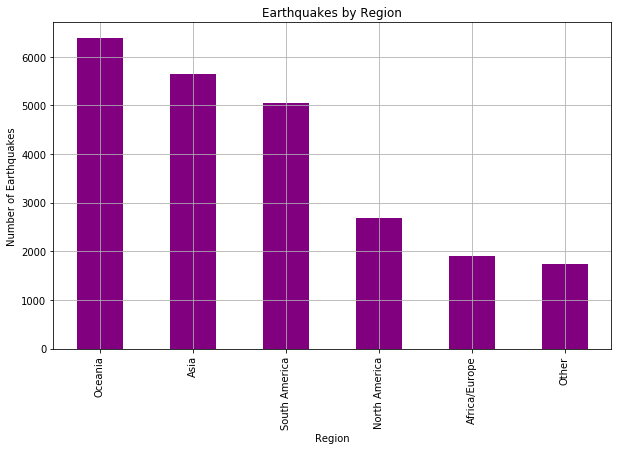

In [19]:
# Now we Visualize the regions.
plt.figure(figsize=(10,6))
region_counts.plot(kind='bar', color='purple')
plt.title("Earthquakes by Region")
plt.xlabel("Region")
plt.ylabel("Number of Earthquakes")
plt.grid(True)
plt.show()


🌍 Analysis 5 — Earthquakes by Region
⭐ This is the answer to Question 5: “Which regions experience the most earthquakes?”

Insight:  
Oceania has the highest number of earthquakes (≈ 6 386), followed by Asia
(≈ 5 644) and South America (≈ 5 057). These regions lie along the Pacific Ring of Fire,
where tectonic plates collide and cause frequent seismic activity. North America,
Africa/Europe, and Other regions show 
significantly fewer events, indicating lower tectonic activity.

### 🟦 Part 4 — Conclusions and Recommendations

🧩 Conclusion
    The earthquake dataset from 1965 to 2015 shows clear global patterns:

    Earthquake frequency increased over time, mainly due to improved monitoring systems.

    Most earthquakes have moderate magnitudes between 5.0 and 6.0.

    Shallow earthquakes (below 100 km) are most common and cause the greatest surface impact.

    The strongest recorded events reached magnitudes 8.3–9.1 in 2004 and 2011.

    Oceania, Asia, and South America experience the highest number of earthquakes, aligning with the Pacific Ring of Fire.

💡 Recommendations
    Focus future monitoring and preparedness efforts in Oceania, Asia, and South America, where seismic activity is most frequent.

    Improve early‑warning systems for shallow earthquakes, as they pose the greatest risk to people and infrastructure.

    Encourage international collaboration for data sharing and real‑time reporting, ensuring consistent global earthquake records.

    Use this dataset for predictive modeling and risk mapping to support disaster‑management planning.



# Part 5 — Tableau Dashboard

This interactive dashboard was created in Tableau using the cleaned earthquake dataset.  
It visualizes earthquake trends by year, magnitude, depth, and region.

🔗 **Dashboard Link:**  
https://public.tableau.com/views/GlobalEarthquakeAnalysisDashboard_17810506947740/EarthquakeDashboard

📷 **Dashboard Preview:**  
![Global Earthquake Dashboard](images_global_earthquake_dashboard.png)



The Tableau dashboard provides an interactive overview of global earthquake activity from 1965–2015. 
It allows users to explore earthquake frequency by year, magnitude distribution, depth distribution, 
and regional patterns. The map visualization highlights where earthquakes occur most frequently.


### Part 6: Final Summary
| **Project Question** | **Analysis Performed** | **Insight (Short & Clear)** |
| --- | --- | --- |
| **[How many earthquakes occur each year?](ca://s?q=Earthquakes_per_year_analysis)** | Line chart: Earthquakes per year | Earthquake counts rise over time mainly because monitoring systems improved, not because more earthquakes happened. |
| **[How are earthquake magnitudes distributed?](ca://s?q=Show_magnitude_distribution)** | Histogram: Magnitude distribution | Most earthquakes have magnitudes between 5.0–6.0. Strong earthquakes (7+) are rare but highly destructive. |
| **[How deep do earthquakes occur?](ca://s?q=Show_depth_distribution)** | Histogram: Depth distribution | Most earthquakes are shallow (0–100 km), where tectonic plates interact. Deep quakes are rare. |
| **[What are the strongest earthquakes?](ca://s?q=Show_top_10_earthquakes)** | Table: Top 10 strongest earthquakes | The strongest events range from magnitude 8.3–9.1, with major ones in 2004 and 2011. Most occur at shallow depths. |
| **[Which regions experience the most earthquakes?](ca://s?q=Earthquakes_by_region_analysis)** | Bar chart: Earthquakes by region | Oceania, Asia, and South America have the most earthquakes due to the Pacific Ring of Fire. |

In [2]:
 # This is just for my personal review: This code is to save the cleaned and processed earthquake data to a new CSV file called "cleaned_earthquake_data.csv". The index=False argument is used to prevent pandas from writing row indices to the CSV file, resulting in a cleaner output. 
 #df.to_csv("cleaned_earthquake_data.csv", index=False)

# Thank you for reviewing this notebook. Every dataset tells a story, and I’m grateful you took the time to discover this one with me.